# Baseline CNN

- 3 convolutional blocks:
    - Conv2D → ReLU → MaxPooling
- Channel progression: 3 → 32 → 64 → 128

**Objective** <br/>
Evaluate whether class-weighted BCE loss improves melanoma detection under class imbalance.

**Changes from baseline** <br/>
- Added pos_weight to BCEWithLogitsLoss
- Kept CNN architecture unchanged

**Hypothesis** <br/>
Weighting the minority melanoma class will improve melanoma recall.

### 1. Import libraries

In [9]:
import sys
import os
sys.path.append(os.path.abspath("../.."))

import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from src.data.dataloader import get_dataloaders
from src.models.cnn_baseline import SimpleCNN
from src.training.trainer import train_one_epoch, validate_one_epoch


from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

### 2. Use MPS

In [10]:
use_mps = True
print("MPS available:", torch.backends.mps.is_available())
device = torch.device("mps" if (use_mps and torch.backends.mps.is_available()) else "cpu")
print(f"Using device: {device}")

MPS available: True
Using device: mps


### 3. Split Dataset 
- Use simpleCNN model
- Use BCEWithLogitsLoss
- Use Adam optimizer

In [11]:
train_loader, val_loader, test_loader = get_dataloaders(
    train_csv="../../data/splits/train.csv",
    val_csv="../../data/splits/val.csv",
    test_csv="../../data/splits/test.csv",
    image_dir="../../data/raw/HAM10000/images",
    batch_size=32,
    image_size=224,
    num_workers=0,
)

train_df = pd.read_csv("../../data/splits/train.csv")

num_neg = (train_df["label"] == 0).sum()   # nevus
num_pos = (train_df["label"] == 1).sum()   # melanoma

pos_weight = torch.tensor([num_neg / num_pos], dtype=torch.float32).to(device)

print("pos_weight:", pos_weight)

model = SimpleCNN().to(device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

pos_weight: tensor([0.1660], device='mps:0')


### 4. Train Model

In [12]:
best_val_loss = float("inf")

num_epochs = 20

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    train_losses.append(train_metrics["loss"])
    val_losses.append(val_metrics["loss"])
    train_accuracies.append(train_metrics["accuracy"])
    val_accuracies.append(val_metrics["accuracy"])

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_metrics['loss']:.4f}, Train Acc: {train_metrics['accuracy']:.4f} | "
        f"Val Loss: {val_metrics['loss']:.4f}, Val Acc: {val_metrics['accuracy']:.4f}"
    )

    # Save best model
    # if val_metrics["loss"] < best_val_loss:
    #     best_val_loss = val_metrics["loss"]
    #     torch.save(model.state_dict(), "../models/cnn_baseline.pth")
    #     print("Saved best model at epoch", epoch+1)

Epoch [1/20] | Train Loss: 0.1077, Train Acc: 0.8565 | Val Loss: 0.0918, Val Acc: 0.8576
Epoch [2/20] | Train Loss: 0.0939, Train Acc: 0.8576 | Val Loss: 0.0970, Val Acc: 0.8576
Epoch [3/20] | Train Loss: 0.0934, Train Acc: 0.8576 | Val Loss: 0.0928, Val Acc: 0.8576
Epoch [4/20] | Train Loss: 0.0914, Train Acc: 0.8576 | Val Loss: 0.0955, Val Acc: 0.8576
Epoch [5/20] | Train Loss: 0.0918, Train Acc: 0.8576 | Val Loss: 0.0916, Val Acc: 0.8576
Epoch [6/20] | Train Loss: 0.0880, Train Acc: 0.8576 | Val Loss: 0.0948, Val Acc: 0.8576
Epoch [7/20] | Train Loss: 0.0870, Train Acc: 0.8576 | Val Loss: 0.0860, Val Acc: 0.8576
Epoch [8/20] | Train Loss: 0.0874, Train Acc: 0.8576 | Val Loss: 0.0875, Val Acc: 0.8576
Epoch [9/20] | Train Loss: 0.0870, Train Acc: 0.8576 | Val Loss: 0.0842, Val Acc: 0.8576
Epoch [10/20] | Train Loss: 0.0843, Train Acc: 0.8578 | Val Loss: 0.0871, Val Acc: 0.8576
Epoch [11/20] | Train Loss: 0.0839, Train Acc: 0.8586 | Val Loss: 0.0863, Val Acc: 0.8576
Epoch [12/20] | Tra

### 5. Plot Loss and Accuracy Curves

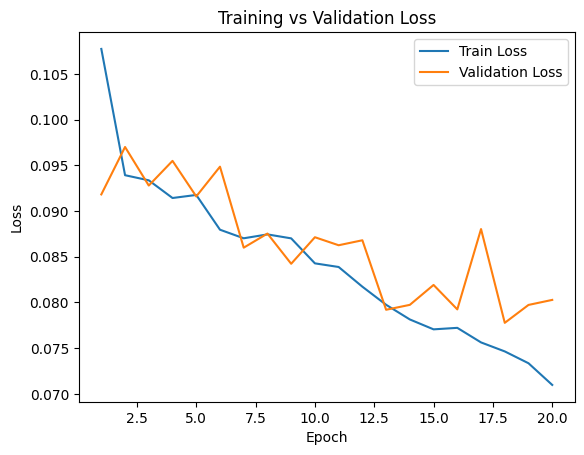

In [13]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure()
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

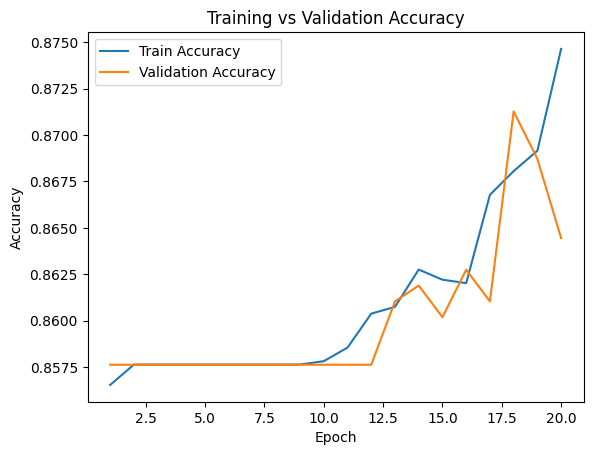

In [14]:
plt.figure()
plt.plot(epochs, train_accuracies, label="Train Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

### 6. Evaluate model
[[TN, FP],<BR/>
 [FN, TP]]

- TN: correctly predicted non-melanoma
- FP: benign predicted as melanoma
- FN: melanoma missed
- TP: correctly predicted melanoma

Precision → “When the model says YES, how often is it correct?” <br/>
Recall → “Out of all actual YES, how many did we catch?”

In [17]:
model.eval()

all_labels = []
all_probs = []
all_preds = []
threshold = 0.5

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= threshold).long()         # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [18]:
from sklearn.metrics import confusion_matrix, classification_report

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1, 0.05]

for threshold in thresholds:
    preds = [1 if p >= threshold else 0 for p in all_probs]
    
    cm = confusion_matrix(all_labels, preds)
    print(f"\nThreshold: {threshold}")
    print("Confusion Matrix:")
    print(cm)
    print(classification_report(all_labels, preds, digits=4))


Threshold: 0.5
Confusion Matrix:
[[1005    1]
 [ 153   14]]
              precision    recall  f1-score   support

           0     0.8679    0.9990    0.9288      1006
           1     0.9333    0.0838    0.1538       167

    accuracy                         0.8687      1173
   macro avg     0.9006    0.5414    0.5413      1173
weighted avg     0.8772    0.8687    0.8185      1173


Threshold: 0.4
Confusion Matrix:
[[1003    3]
 [ 145   22]]
              precision    recall  f1-score   support

           0     0.8737    0.9970    0.9313      1006
           1     0.8800    0.1317    0.2292       167

    accuracy                         0.8738      1173
   macro avg     0.8768    0.5644    0.5802      1173
weighted avg     0.8746    0.8738    0.8313      1173


Threshold: 0.3
Confusion Matrix:
[[999   7]
 [134  33]]
              precision    recall  f1-score   support

           0     0.8817    0.9930    0.9341      1006
           1     0.8250    0.1976    0.3188       167

   

In [19]:
model.eval()

all_labels = []
all_probs = []
all_preds = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)                      # raw logits
        probs = torch.sigmoid(outputs).squeeze(1)    # probabilities
        preds = (probs >= 0.05)            # binary predictions

        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [20]:
cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[939  67]
 [ 70  97]]


In [21]:
print(classification_report(all_labels, all_preds, digits=4))

              precision    recall  f1-score   support

           0     0.9306    0.9334    0.9320      1006
           1     0.5915    0.5808    0.5861       167

    accuracy                         0.8832      1173
   macro avg     0.7610    0.7571    0.7591      1173
weighted avg     0.8823    0.8832    0.8828      1173



**much better** 

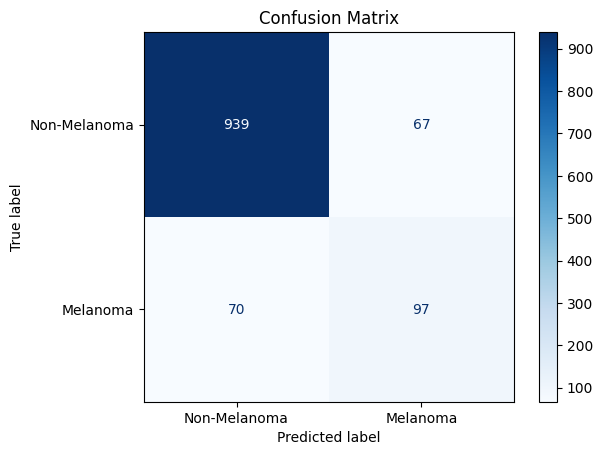

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Melanoma", "Melanoma"])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()